In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, 
    average_precision_score, confusion_matrix, classification_report
)

In [2]:
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
train_df = pd.read_csv('../data/processed/train_data_clean.csv')
test_df = pd.read_csv('../data/processed/test_data_clean.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train readmission rate: {train_df['readmitted_30d'].mean():.2%}")
print(f"Test readmission rate: {test_df['readmitted_30d'].mean():.2%}")

Train shape: (324824, 53)
Test shape: (81207, 53)
Train readmission rate: 17.32%
Test readmission rate: 17.90%


In [3]:
# Drop non-predictive columns
drop_cols = [
    'subject_id', 'hadm_id', 'admittime', 'dischtime',
    'readmitted_30d', 'readmitted_60d', 'readmitted_90d',
]

X_train = train_df.drop(columns=drop_cols, errors='ignore')
y_train = train_df['readmitted_30d']

X_test = test_df.drop(columns=drop_cols, errors='ignore')
y_test = test_df['readmitted_30d']

print(f"Features: {X_train.shape[1]}")
print(f"Feature list: {X_train.columns.tolist()}")

# One-hot encode categoricals
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical features: {categorical_cols}")

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)
print(f"\nAfter encoding: {X_train_encoded.shape[1]} features")

Features: 46
Feature list: ['gender', 'age', 'race', 'marital_status', 'language', 'insurance', 'admission_type', 'admission_location', 'discharge_location', 'los_hours', 'los_days', 'num_diagnoses', 'cci_mi', 'cci_chf', 'cci_pvd', 'cci_cvd', 'cci_dementia', 'cci_copd', 'cci_diabetes', 'cci_ckd', 'cci_cancer', 'num_lab_tests_24h', 'num_abnormal_labs', 'hemoglobin_min', 'wbc_max', 'creatinine_max', 'sodium_min', 'sodium_max', 'potassium_min', 'potassium_max', 'glucose_min', 'glucose_max', 'num_medications', 'polypharmacy_flag', 'anticoagulant_flag', 'insulin_flag', 'opioid_flag', 'antibiotic_flag', 'num_admissions_last_30d', 'num_admissions_last_90d', 'num_admissions_last_year', 'days_since_last_discharge', 'total_prior_admissions', 'recent_admission_flag', 'frequent_flyer_flag', 'has_prior_admission']

Categorical features: ['gender', 'race', 'marital_status', 'language', 'insurance', 'admission_type', 'admission_location', 'discharge_location']

After encoding: 135 features


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Features standardized")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Features standardized
Train shape: (324824, 135)
Test shape: (81207, 135)


In [7]:
print("MODEL 1: LOGISTIC REGRESSION (No Class Balancing)")

lr_baseline = LogisticRegression(max_iter=1000, random_state=42, solver='saga')
lr_baseline.fit(X_train_scaled, y_train)

y_train_pred_proba = lr_baseline.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = lr_baseline.predict_proba(X_test_scaled)[:, 1]

train_auroc = roc_auc_score(y_train, y_train_pred_proba)
test_auroc = roc_auc_score(y_test, y_test_pred_proba)
train_auprc = average_precision_score(y_train, y_train_pred_proba)
test_auprc = average_precision_score(y_test, y_test_pred_proba)

print(f"Train AUROC: {train_auroc:.4f} | Test AUROC: {test_auroc:.4f}")
print(f"Train AUPRC: {train_auprc:.4f} | Test AUPRC: {test_auprc:.4f}")

results = {
    'Model': ['LR Baseline'],
    'Train AUROC': [train_auroc], 'Test AUROC': [test_auroc],
    'Train AUPRC': [train_auprc], 'Test AUPRC': [test_auprc]
}

MODEL 1: LOGISTIC REGRESSION (No Class Balancing)
Train AUROC: 0.7072 | Test AUROC: 0.7021
Train AUPRC: 0.3523 | Test AUPRC: 0.3506


In [8]:
print("MODEL 2: LOGISTIC REGRESSION (Class Weights)")

lr_weighted = LogisticRegression(max_iter=1000, random_state=42, solver='saga', class_weight='balanced')
lr_weighted.fit(X_train_scaled, y_train)

y_train_pred_proba_w = lr_weighted.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_w = lr_weighted.predict_proba(X_test_scaled)[:, 1]

train_auroc_w = roc_auc_score(y_train, y_train_pred_proba_w)
test_auroc_w = roc_auc_score(y_test, y_test_pred_proba_w)
train_auprc_w = average_precision_score(y_train, y_train_pred_proba_w)
test_auprc_w = average_precision_score(y_test, y_test_pred_proba_w)

print(f"Train AUROC: {train_auroc_w:.4f} | Test AUROC: {test_auroc_w:.4f}")
print(f"Train AUPRC: {train_auprc_w:.4f} | Test AUPRC: {test_auprc_w:.4f}")

results['Model'].append('LR Class Weights')
results['Train AUROC'].append(train_auroc_w)
results['Test AUROC'].append(test_auroc_w)
results['Train AUPRC'].append(train_auprc_w)
results['Test AUPRC'].append(test_auprc_w)

MODEL 2: LOGISTIC REGRESSION (Class Weights)
Train AUROC: 0.7078 | Test AUROC: 0.7025
Train AUPRC: 0.3514 | Test AUPRC: 0.3499


In [9]:
print("MODEL 3: LOGISTIC REGRESSION (SMOTE)")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original: {np.bincount(y_train)} → SMOTE: {np.bincount(y_train_smote)}")

lr_smote = LogisticRegression(max_iter=1000, random_state=42, solver='saga')
lr_smote.fit(X_train_smote, y_train_smote)

y_train_pred_proba_s = lr_smote.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_s = lr_smote.predict_proba(X_test_scaled)[:, 1]

train_auroc_s = roc_auc_score(y_train, y_train_pred_proba_s)
test_auroc_s = roc_auc_score(y_test, y_test_pred_proba_s)
train_auprc_s = average_precision_score(y_train, y_train_pred_proba_s)
test_auprc_s = average_precision_score(y_test, y_test_pred_proba_s)

print(f"Train AUROC: {train_auroc_s:.4f} | Test AUROC: {test_auroc_s:.4f}")
print(f"Train AUPRC: {train_auprc_s:.4f} | Test AUPRC: {test_auprc_s:.4f}")

results['Model'].append('LR SMOTE')
results['Train AUROC'].append(train_auroc_s)
results['Test AUROC'].append(test_auroc_s)
results['Train AUPRC'].append(train_auprc_s)
results['Test AUPRC'].append(test_auprc_s)

MODEL 3: LOGISTIC REGRESSION (SMOTE)
Original: [268570  56254] → SMOTE: [268570 268570]
Train AUROC: 0.7038 | Test AUROC: 0.6984
Train AUPRC: 0.3498 | Test AUPRC: 0.3479


In [10]:

print("MODEL 4: XGBOOST")

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"Scale pos weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train_encoded, y_train)

y_train_pred_proba_xgb = xgb_model.predict_proba(X_train_encoded)[:, 1]
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

train_auroc_xgb = roc_auc_score(y_train, y_train_pred_proba_xgb)
test_auroc_xgb = roc_auc_score(y_test, y_test_pred_proba_xgb)
train_auprc_xgb = average_precision_score(y_train, y_train_pred_proba_xgb)
test_auprc_xgb = average_precision_score(y_test, y_test_pred_proba_xgb)

print(f"Train AUROC: {train_auroc_xgb:.4f} | Test AUROC: {test_auroc_xgb:.4f}")
print(f"Train AUPRC: {train_auprc_xgb:.4f} | Test AUPRC: {test_auprc_xgb:.4f}")

results['Model'].append('XGBoost')
results['Train AUROC'].append(train_auroc_xgb)
results['Test AUROC'].append(test_auroc_xgb)
results['Train AUPRC'].append(train_auprc_xgb)
results['Test AUPRC'].append(test_auprc_xgb)

MODEL 4: XGBOOST
Scale pos weight: 4.77
Train AUROC: 0.7313 | Test AUROC: 0.7159
Train AUPRC: 0.3909 | Test AUPRC: 0.3688


In [11]:
results_df = pd.DataFrame(results)


print("MODEL COMPARISON - 30-DAY READMISSION PREDICTION")

print(results_df.to_string(index=False))


best_test_auroc = results_df['Test AUROC'].max()
best_model = results_df[results_df['Test AUROC'] == best_test_auroc]['Model'].values[0]
print(f"\nBEST MODEL: {best_model}")
print(f"   Test AUROC: {best_test_auroc:.4f}")

if best_test_auroc >= 0.75:
    print(f"\nTARGET MET: AUROC ≥ 0.75 achieved!")
else:
    print(f"\n⚠TARGET NOT MET: Gap = {0.75 - best_test_auroc:.4f}")

import os
os.makedirs('../results', exist_ok=True)
results_df.to_csv('../results/baseline_model_comparison.csv', index=False)
print("\nSaved to results/baseline_model_comparison.csv")

MODEL COMPARISON - 30-DAY READMISSION PREDICTION
           Model  Train AUROC  Test AUROC  Train AUPRC  Test AUPRC
     LR Baseline     0.707214    0.702142     0.352323    0.350643
LR Class Weights     0.707783    0.702503     0.351358    0.349873
        LR SMOTE     0.703836    0.698398     0.349832    0.347871
         XGBoost     0.731263    0.715879     0.390942    0.368807

BEST MODEL: XGBoost
   Test AUROC: 0.7159

⚠TARGET NOT MET: Gap = 0.0341

Saved to results/baseline_model_comparison.csv


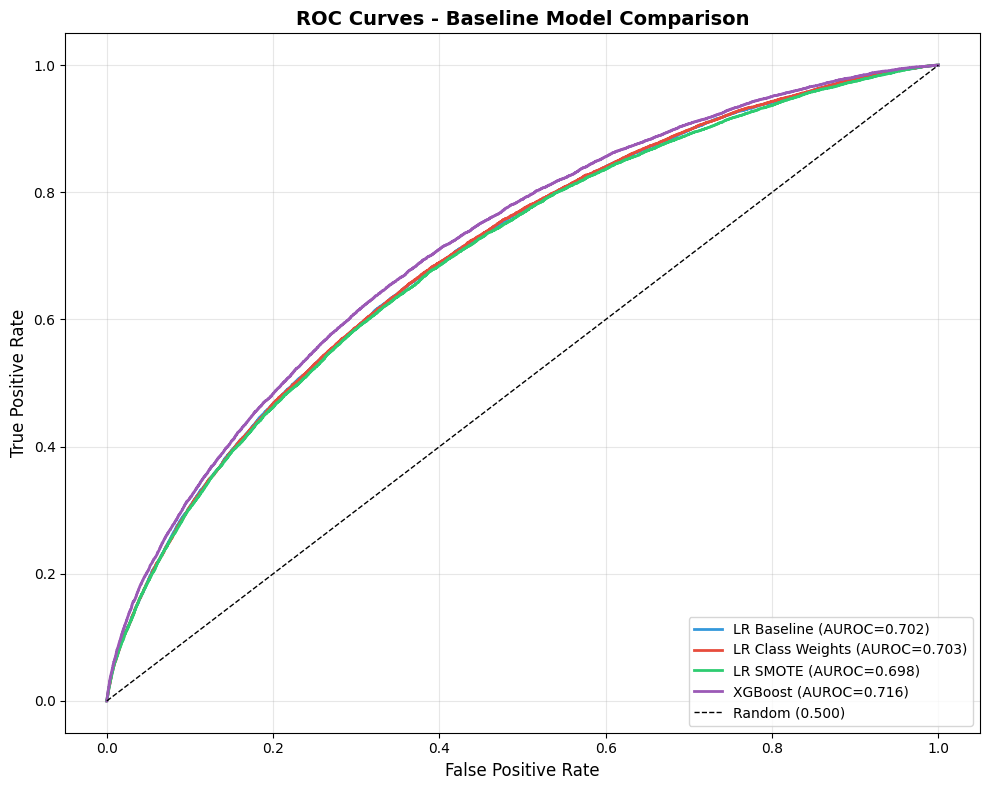

✅ Saved ROC curve


In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

models_to_plot = [
    ('LR Baseline', y_test_pred_proba, '#3498db'),
    ('LR Class Weights', y_test_pred_proba_w, '#e74c3c'),
    ('LR SMOTE', y_test_pred_proba_s, '#2ecc71'),
    ('XGBoost', y_test_pred_proba_xgb, '#9b59b6')
]

for name, y_pred, color in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    auroc = roc_auc_score(y_test, y_pred)
    ax.plot(fpr, tpr, label=f'{name} (AUROC={auroc:.3f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random (0.500)', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Baseline Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/roc_curves_baseline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved ROC curve")

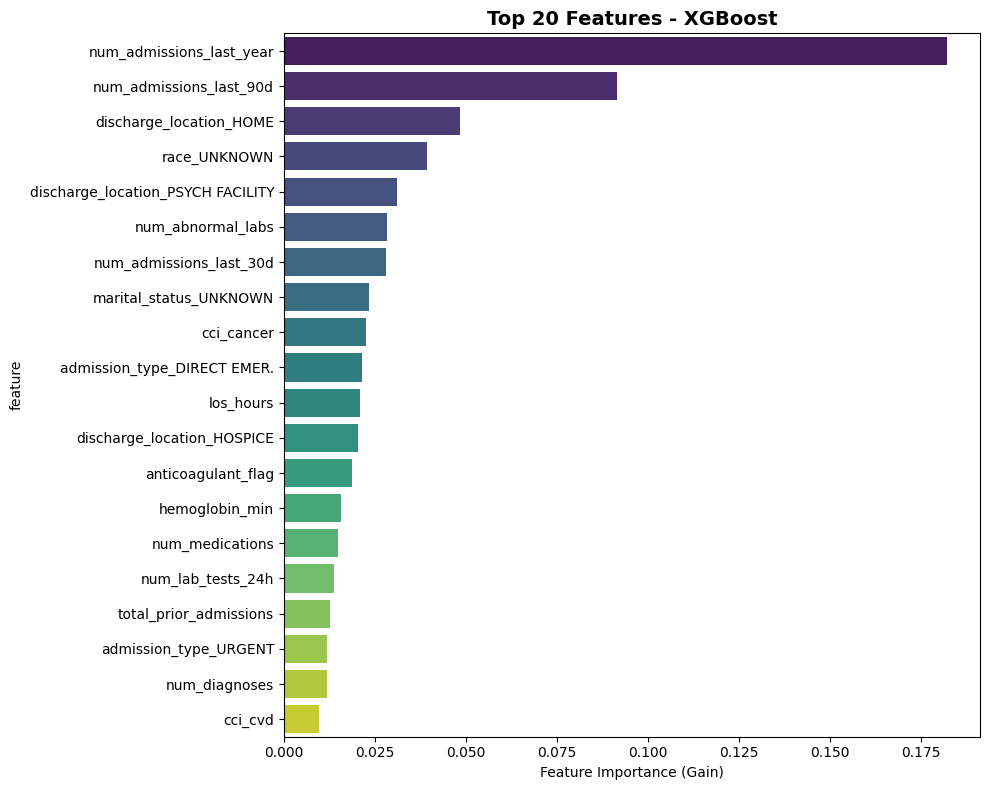


Top 10 Features:
                          feature  importance
         num_admissions_last_year    0.182059
          num_admissions_last_90d    0.091344
          discharge_location_HOME    0.048231
                     race_UNKNOWN    0.039222
discharge_location_PSYCH FACILITY    0.031121
                num_abnormal_labs    0.028334
          num_admissions_last_30d    0.028051
           marital_status_UNKNOWN    0.023328
                       cci_cancer    0.022485
      admission_type_DIRECT EMER.    0.021571


In [13]:
import matplotlib.pyplot as plt

feature_names = X_train_encoded.columns.tolist()
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 20 Features - XGBoost', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('../results/xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(feat_imp.head(10).to_string(index=False))